# Tuning Hurdle Model

**AIM: Optimize the sensitivity of the classifiers; tune models for max recall**

Choices based on 04_classifier.ipynb and 05_hurdle.ipynb:

1. Flase negatives are costly in stage 1; must get higher recall for carbon (05_hurdle.ipynb)
2. Will only predict the main three N-sources rather than each individual C-source (04_classifier.ipynb)
3. Test prediction of primary nutrient and oxygen uptake only 
4. Tuning of classification stages is most important (05_hurdle.ipynb in combo with previous regression tests and mapping analyses)
5. Might test log-transforming target at regression stage

In [ ]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

# if notebook is in notebooks/, go up one level
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("ggplot")

import numpy as np
import seaborn as sns

In [81]:
from xgboost import XGBRegressor, XGBClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline

# data prep and plotting etc:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Tuning:
from sklearn.model_selection import KFold, StratifiedKFold, RandomizedSearchCV, GridSearchCV, learning_curve, LearningCurveDisplay
from sklearn.metrics import roc_curve, precision_recall_curve, auc, make_scorer, recall_score, roc_auc_score

# evaluation:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import confusion_matrix, accuracy_score, multilabel_confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

### Functions:

In [26]:
def plot_binary_eval_curves(y_true, y_score, figsize=(18, 5)):
    """
    Plot three binary-classification evaluation curves side by side:
    1) Precision-Recall curve
    2) Precision and Recall vs Decision Threshold
    3) ROC curve

    Parameters
    ----------
    y_true : array-like
        True binary labels (0/1 or False/True).
    y_score : array-like
        Predicted scores or probabilities for the positive class.
    figsize : tuple, optional
        Figure size for the subplot layout.
    """
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_score)
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # 1) Precision-Recall curve
    axes[0].plot(recall, precision, "b-", alpha=0.5)
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")
    axes[0].set_title("Precision–Recall Curve", fontsize=10)


    # 2) Precision and Recall vs threshold
    axes[1].plot(pr_thresholds, precision[:-1], "b--", label="Precision")
    axes[1].plot(pr_thresholds, recall[:-1], "-", label="Recall")
    axes[1].set_xlabel("Decision Threshold")
    axes[1].set_ylabel("Score")
    axes[1].set_title("Score vs Decision Threshold", fontsize=10)
    axes[1].legend()


    # 3) ROC curve
    axes[2].plot(fpr, tpr, "-", color='orange', label=f"AUC = {roc_auc:.3f}")
    axes[2].plot([0, 1], [0, 1], "k--")
    axes[2].set_xlabel("False Positive Rate")
    axes[2].set_ylabel("True Positive Rate (Recall)")
    axes[2].set_title("ROC Curve", fontsize=10)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

### Load Data

In [143]:
train_data = pd.read_pickle(DATA/"ml_datasets/TRAIN_raw.pkl")
features = pd.read_pickle(DATA/"ml_datasets/L2_FEATURES_ML.pkl")

rxn_cols = ['EX_o2_e','EX_glc__D_e', 'EX_ac_e', 'EX_lcts_e', 'EX_glyc_e', 'EX_succ_e','EX_arg__L_e', 'EX_nh4_e', 'EX_no3_e']

In [222]:
target = train_data[rxn_cols]
target = (-target.clip(upper=0))
target[target == 0] = 0 # to avoid negative

target['source'] = train_data['source'].str.split('_').str[0] #less specific nitrogen source
target['source_type'] = target['source'].str.contains(r'arg|nh4|no3', case=False, na=False).map({True: 'nitrogen', False: 'carbon'})

### Split into train and validation

In [223]:
X = features.copy()
Y = target.copy()

In [224]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=0, stratify=Y['source'])

**Encoding Targets for the different stages**

* Stage 1:

In [225]:
Y_train_type = Y_train['source_type']
Y_val_type = Y_val['source_type']

le_type = LabelEncoder()
Y_train_type_enc = le_type.fit_transform(Y_train_type)
Y_val_type_enc = le_type.transform(Y_val_type)

*C=0; want to imporve recall for C*

* Stage 2:

In [226]:
Y_train_source = Y_train['source']
Y_val_source = Y_val['source']

le_source = LabelEncoder()
Y_train_source_enc = le_source.fit_transform(Y_train_source)
Y_val_source_enc = le_source.transform(Y_val_source)

c_mask_train = (Y_train['source_type'] == "carbon")
c_mask_val = (Y_val['source_type'] == "carbon")
n_mask_train = (Y_train['source_type'] == "nitrogen")
n_mask_val = (Y_val['source_type'] == "nitrogen")

# subset X
X_train_c = X_train[c_mask_train]
X_val_c = X_val[c_mask_val]
X_train_n = X_train[n_mask_train]
X_val_n = X_val[n_mask_val]

# subset source labels
Y_train_c = Y_train_source[c_mask_train]
Y_val_c = Y_val_source[c_mask_val]
Y_train_n = Y_train_source[n_mask_train]
Y_val_n = Y_val_source[n_mask_val]

le_carbon = LabelEncoder()
le_nitrogen = LabelEncoder()

Y_train_c_enc = le_carbon.fit_transform(Y_train_c)
Y_val_c_enc = le_carbon.transform(Y_val_c)

Y_train_n_enc = le_nitrogen.fit_transform(Y_train_n)
Y_val_n_enc = le_nitrogen.transform(Y_val_n)

* Stage 3:

In [227]:
Y_train_num = Y_train.iloc[:, :9]
Y_val_num = Y_val.iloc[:, :9]

## Training Each Stage Model:

In [228]:
binary_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

binary_clf.fit(X_train, Y_train_type_enc)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [229]:
carbon_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

nitrogen_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

carbon_clf.fit(X_train_c, Y_train_c_enc)
nitrogen_clf.fit(X_train_n, Y_train_n_enc)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [230]:
# STAGE 1 (Carbon or Nitrogen):
binary_proba_train = binary_clf.predict_proba(X_train) # is a bit optimistic, but it is how it has been implemented elsewhere

# STAGE 2 (WHICH CARBON OR WHICH NITROGEN):
n_train = len(X_train)
carbon_proba_train = np.zeros((n_train, len(le_carbon.classes_)))
nitrogen_proba_train = np.zeros((n_train, len(le_nitrogen.classes_)))

carbon_label = le_type.transform(["carbon"])[0]
nitrogen_label = le_type.transform(["nitrogen"])[0]

carbon_mask_train = c_mask_train.to_numpy()
nitrogen_mask_train = n_mask_train.to_numpy()

carbon_proba_train[carbon_mask_train] = carbon_clf.predict_proba(X_train.iloc[carbon_mask_train])
nitrogen_proba_train[nitrogen_mask_train] = nitrogen_clf.predict_proba(X_train.iloc[nitrogen_mask_train])

X_train_global = np.hstack([X_train, binary_proba_train, carbon_proba_train, nitrogen_proba_train])

In [231]:
global_reg = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
    )
)

global_reg.fit(X_train_global, Y_train_num)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,RandomForestR...ndom_state=42)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least o

### Functions for training etc:

In [103]:
def make_prediction2(X):
    binary_proba = binary_clf.predict_proba(X)

    carbon_label = le_type.transform(["carbon"])[0]
    nitrogen_label = le_type.transform(["nitrogen"])[0]

    carbon_idx_col = list(binary_clf.classes_).index(carbon_label)
    nitrogen_idx_col = list(binary_clf.classes_).index(nitrogen_label)

    binary_pred = binary_clf.predict(X)

    carbon_idx = np.where(binary_pred == carbon_label)[0]
    nitrogen_idx = np.where(binary_pred == nitrogen_label)[0]

    carbon_source_proba = np.zeros((len(X), len(le_carbon.classes_)))
    nitrogen_source_proba = np.zeros((len(X), len(le_nitrogen.classes_)))

    if len(carbon_idx) > 0:
        carbon_source_proba[carbon_idx] = carbon_clf.predict_proba(X.iloc[carbon_idx])
    if len(nitrogen_idx) > 0:
        nitrogen_source_proba[nitrogen_idx] = nitrogen_clf.predict_proba(X.iloc[nitrogen_idx])

    X_global = np.hstack([X, binary_proba, carbon_source_proba, nitrogen_source_proba])
    

    uptake_pred = global_reg.predict(X_global)

    source_pred = np.empty(len(X), dtype=object)
    if len(carbon_idx) > 0:
        source_pred[carbon_idx] = carbon_clf.predict(X.iloc[carbon_idx])
    if len(nitrogen_idx) > 0:
        source_pred[nitrogen_idx] = nitrogen_clf.predict(X.iloc[nitrogen_idx])

    return binary_pred, source_pred, uptake_pred

In [208]:
# def make_prediction3(binary_classifier, X, threshold=0.5):
#     clf = binary_classifier
#     binary_proba = clf.predict_proba(X)

#     carbon_label = le_type.transform(["carbon"])[0]
#     nitrogen_label = le_type.transform(["nitrogen"])[0]

#     carbon_idx_col = list(clf.classes_).index(carbon_label)

#     carbon_proba = binary_proba[:, carbon_idx_col]

#     binary_pred = np.where(
#         carbon_proba >= threshold,
#         carbon_label,
#         nitrogen_label
#     )

#     carbon_idx = np.where(binary_pred == carbon_label)[0]
#     nitrogen_idx = np.where(binary_pred == nitrogen_label)[0]

#     carbon_source_proba = np.zeros((len(X), len(le_carbon.classes_)))
#     nitrogen_source_proba = np.zeros((len(X), len(le_nitrogen.classes_)))

#     if len(carbon_idx) > 0:
#         carbon_source_proba[carbon_idx] = carbon_clf.predict_proba(X.iloc[carbon_idx])

#     if len(nitrogen_idx) > 0:
#         nitrogen_source_proba[nitrogen_idx] = nitrogen_clf.predict_proba(X.iloc[nitrogen_idx])

#     X_global = np.hstack([X, binary_proba, carbon_source_proba, nitrogen_source_proba])

#     uptake_pred = global_reg.predict(X_global)

#     source_pred = np.empty(len(X), dtype=object)
#     if len(carbon_idx) > 0:
#         source_pred[carbon_idx] = carbon_clf.predict(X.iloc[carbon_idx])
#     if len(nitrogen_idx) > 0:
#         source_pred[nitrogen_idx] = nitrogen_clf.predict(X.iloc[nitrogen_idx])

#     return binary_pred, source_pred, uptake_pred

In [209]:
def make_prediction3(binary_classifier, X, threshold=0.5):
    clf = binary_classifier
    binary_proba = clf.predict_proba(X)

    carbon_label = le_type.transform(["carbon"])[0]
    nitrogen_label = le_type.transform(["nitrogen"])[0]

    carbon_idx_col = list(clf.classes_).index(carbon_label)

    carbon_proba = binary_proba[:, carbon_idx_col]

    binary_pred = np.where(
        carbon_proba >= threshold,
        carbon_label,
        nitrogen_label
    )

    carbon_idx = np.where(binary_pred == carbon_label)[0]
    nitrogen_idx = np.where(binary_pred == nitrogen_label)[0]

    carbon_source_proba = np.zeros((len(X), len(le_carbon.classes_)))
    nitrogen_source_proba = np.zeros((len(X), len(le_nitrogen.classes_)))

    if len(carbon_idx) > 0:
        carbon_source_proba[carbon_idx] = carbon_clf.predict_proba(X.iloc[carbon_idx])

    if len(nitrogen_idx) > 0:
        nitrogen_source_proba[nitrogen_idx] = nitrogen_clf.predict_proba(X.iloc[nitrogen_idx])

    X_global = np.hstack([X, binary_proba, carbon_source_proba, nitrogen_source_proba])

    uptake_pred = global_reg.predict(X_global)

    source_pred = np.empty(len(X), dtype=object)
    if len(carbon_idx) > 0:
        source_pred[carbon_idx] = le_carbon.inverse_transform(
            carbon_clf.predict(X.iloc[carbon_idx])
        )
    if len(nitrogen_idx) > 0:
        source_pred[nitrogen_idx] = le_nitrogen.inverse_transform(
            nitrogen_clf.predict(X.iloc[nitrogen_idx])
        )

    return binary_pred, source_pred, uptake_pred

In [127]:
def plot_all_targets_grid(y_true_df, y_pred_array, color='darkcyan', title=None):
    target_names = y_true_df.columns
    n_targets = len(target_names)
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.flatten()

    for i, col in enumerate(target_names):
        ax = axes[i]
        y_true = y_true_df.iloc[:, i].values
        y_p = y_pred_array[:, i]
        
        # Plotting the scatter points
        ax.scatter(y_true, y_p, alpha=0.3, color=color, s=10, label='Data Points')
        
        # Calculate limits for the identity line (y=x)
        max_val = max(np.max(y_true), np.max(y_p))
        ax.plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Perfect Fit')
        
        # Add titles and labels
        ax.set_title(f"Target: {col}", fontsize=14, fontweight='bold')
        ax.set_xlabel("True Flux", fontsize=10)
        ax.set_ylabel("Predicted Flux", fontsize=10)
        ax.grid(True, alpha=0.2)
        
        # Optional: Add the R2/MAE text inside the plot for easy reference
        from sklearn.metrics import r2_score
        r2 = r2_score(y_true, y_p)
        ax.text(0.05, 0.95, f'$R^2$: {r2:.2f}', transform=ax.transAxes, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    # Adjust layout to prevent overlap
    plt.suptitle(title, fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()


# Tuning

## 1.1 - Baseline Binary Classifier

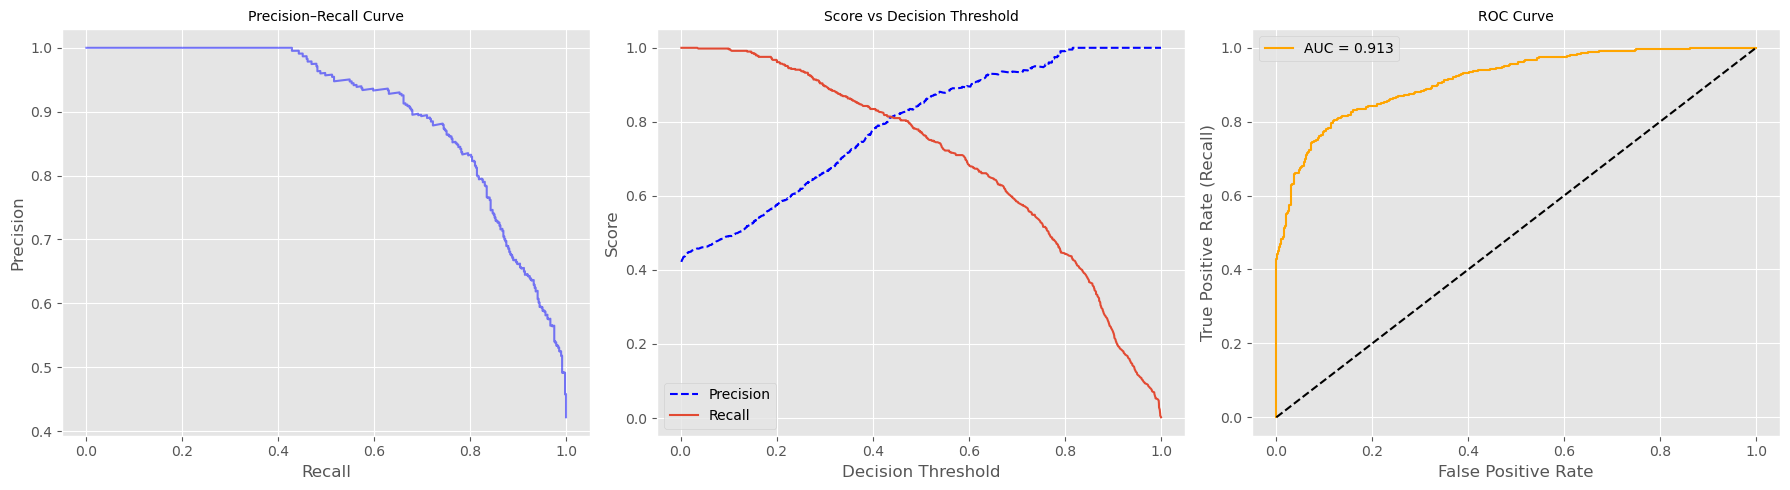

In [232]:
y_score_default = binary_clf.predict_proba(X_val)[:, 0]
y_true_c = (Y_val_type_enc == 0).astype(int)

plot_binary_eval_curves(y_true_c, y_score_default)

* PR curve: high sensitivity means i must accept more false positives
* Score vs threshold: lower thershold increases recall, but decreases precision too
    * critical region threshold~0.3-0.5
    * threshold dominates performance
* ROC curve: classifier is strong; classifier is able to separate C vs N across all thresholds
    * above i have plotted for Carbon as positive; this means that if a random sample is picked there is a 91,3% chance that Carbon gets a higher score

In [233]:
Y_pred_val_df = binary_clf.predict(X_val)
print(classification_report(Y_val_type_enc, Y_pred_val_df, target_names=le_type.classes_))

              precision    recall  f1-score   support

      carbon       0.85      0.77      0.81       490
    nitrogen       0.84      0.90      0.87       672

    accuracy                           0.85      1162
   macro avg       0.85      0.84      0.84      1162
weighted avg       0.85      0.85      0.85      1162



***

In [255]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

grid_search = GridSearchCV(
    estimator=binary_clf,
    param_grid=param_grid,
    cv=skf,
    n_jobs=-1,
    verbose=1,
)

PRØV Å FÅ DETTE IGJEN, OG BARE BEHOLD DET. GÅ VIDERE OG TUNE NESTE CLASSIFIER, OG SÅ ER DET OVER
Best params: {'class_weight': None, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

In [256]:
grid_search.fit(X_train, Y_train_type_enc)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


KeyboardInterrupt: 

In [ ]:
best_binary_clf = grid_search.best_estimator_

print("Best params:", grid_search.best_params_)

Best params: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
model = best_binary_clf
print("Train score:", model.score(X_train, Y_train_type_enc))
print("Val score:", model.score(X_val, Y_val_type_enc))

Train score: 0.7476313522825151
Val score: 0.7271944922547332


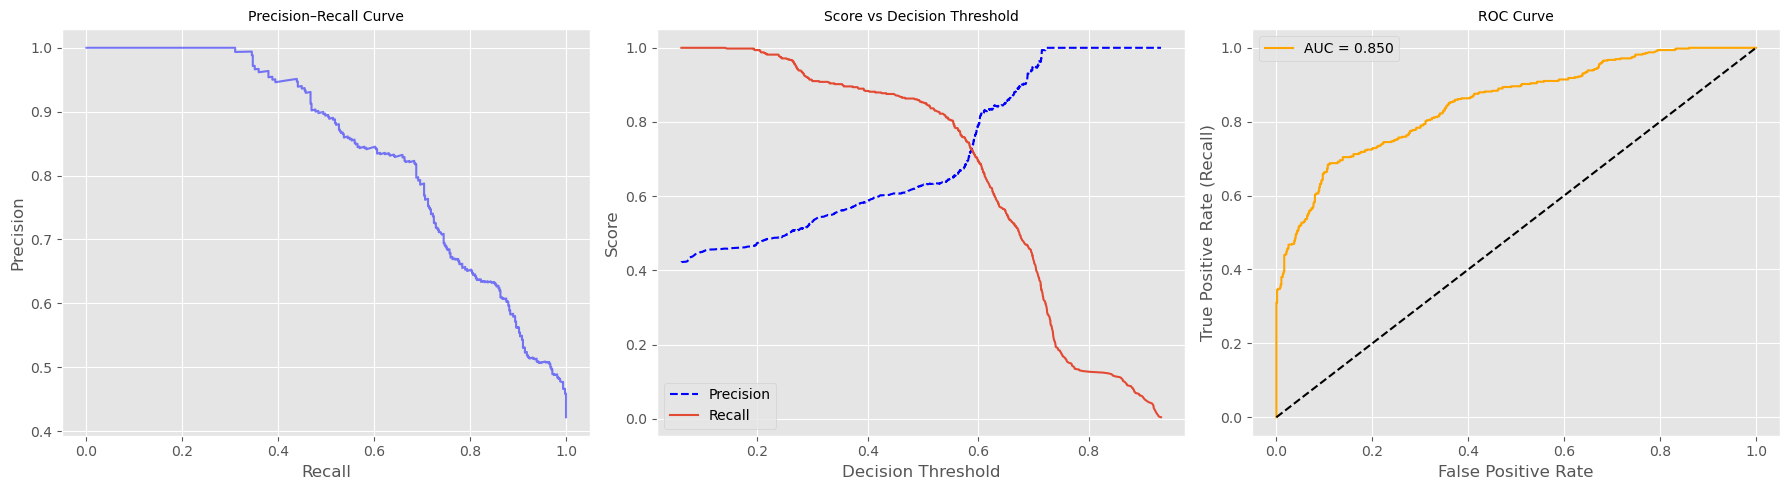

In [252]:
y_score = best_binary_clf.predict_proba(X_val)[:, 0]
y_true_c = (Y_val_type_enc == 0).astype(int)

plot_binary_eval_curves(y_true_c, y_score)

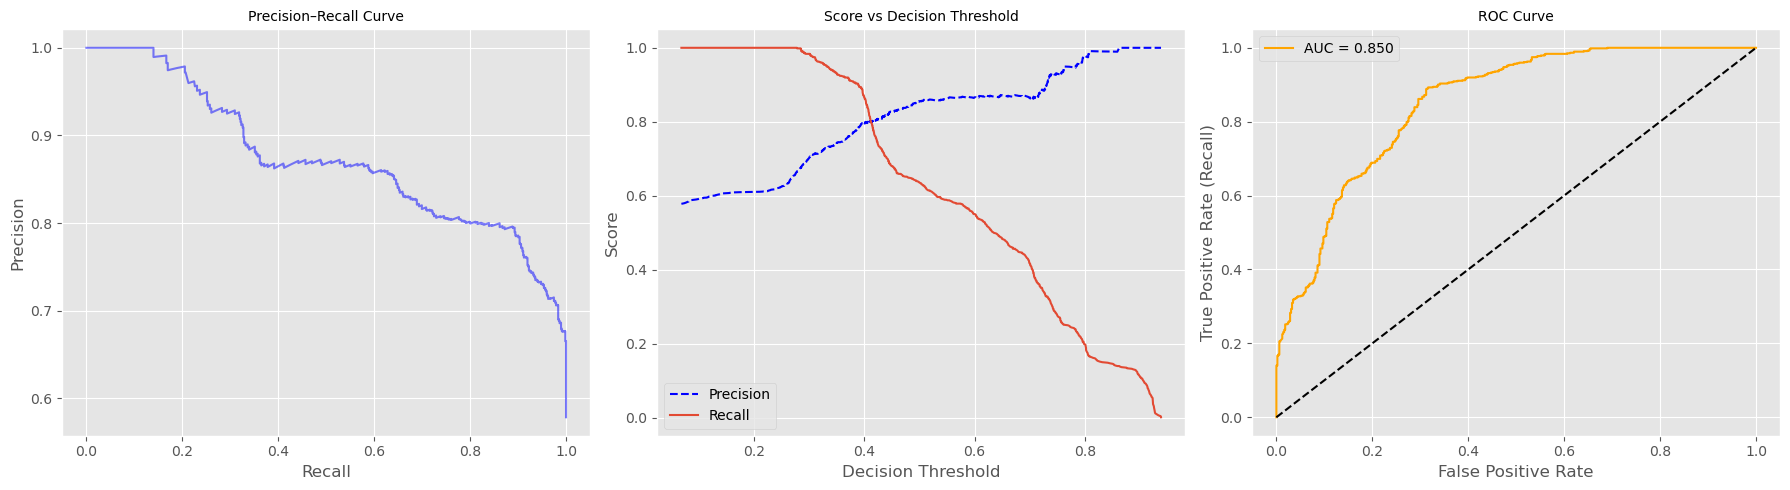

In [253]:
y_score = best_binary_clf.predict_proba(X_val)[:, 1]
y_true_n = (Y_val_type_enc == 1).astype(int)

plot_binary_eval_curves(y_true_n, y_score)

In [254]:
Y_pred_best = best_binary_clf.predict(X_val)
print(classification_report(Y_val_type_enc, Y_pred_best, target_names=le_type.classes_))

              precision    recall  f1-score   support

      carbon       0.63      0.85      0.73       490
    nitrogen       0.86      0.64      0.73       672

    accuracy                           0.73      1162
   macro avg       0.74      0.74      0.73      1162
weighted avg       0.76      0.73      0.73      1162



In [239]:
depths = [estimator.tree_.max_depth for estimator in best_binary_clf.estimators_]

print("Max depth (deepest tree):", max(depths))
print("Average depth:", sum(depths) / len(depths))

Max depth (deepest tree): 20
Average depth: 20.0


* Carbon recall increased, and not at the expence of nitrogen precision or recall
* GridSearch took 7min9s

* results here are a bit different because of fewer source lables for nitrogen sources

### Testing best_binary_clf with different thresholds:

In [210]:
binary_pred_val, source_pred_val, uptake_pred_val = make_prediction3(best_binary_clf, X_val, threshold=0.5)

In [211]:
print(classification_report(Y_val_type_enc, binary_pred_val, target_names=le_type.classes_))

              precision    recall  f1-score   support

      carbon       0.87      0.79      0.83       490
    nitrogen       0.86      0.92      0.89       672

    accuracy                           0.86      1162
   macro avg       0.87      0.85      0.86      1162
weighted avg       0.86      0.86      0.86      1162



In [216]:
print(classification_report(Y_val_c_enc, carbon_clf.predict(X_val_c), target_names=le_carbon.classes_))

              precision    recall  f1-score   support

          ac       0.82      0.88      0.85        77
         glc       0.80      0.74      0.77       112
        glyc       0.82      0.54      0.65        93
        lcts       0.68      0.93      0.79       126
        succ       0.94      0.80      0.87        82

    accuracy                           0.78       490
   macro avg       0.81      0.78      0.78       490
weighted avg       0.80      0.78      0.78       490



In [215]:
carbon_idx = (binary_pred_val == carbon_label)

carbon_pred = source_pred_val[carbon_idx]
carbon_true = Y_val_source[carbon_idx]

print(classification_report(Y_val_source[carbon_idx], source_pred_val[carbon_idx], labels=le_carbon.classes_))

              precision    recall  f1-score   support

          ac       0.54      0.73      0.62        30
         glc       0.74      0.72      0.73        99
        glyc       0.67      0.56      0.61        70
        lcts       0.64      0.97      0.77       116
        succ       0.82      0.84      0.83        73

   micro avg       0.69      0.79      0.73       388
   macro avg       0.68      0.76      0.71       388
weighted avg       0.70      0.79      0.73       388



In [221]:
print(classification_report(Y_val_n_enc, nitrogen_clf.predict(X_val_n), target_names=le_nitrogen.classes_, zero_division=0))

              precision    recall  f1-score   support

      arg_ac       0.62      0.77      0.69        93
     arg_glc       0.65      0.67      0.66       107
    arg_glyc       0.72      0.70      0.71       104
      nh4_ac       0.80      0.68      0.74        47
     nh4_glc       0.85      0.92      0.88       110
      no3_ac       0.00      0.00      0.00         6
     no3_glc       0.75      0.75      0.75       110
    no3_glyc       0.85      0.67      0.75        95

    accuracy                           0.74       672
   macro avg       0.66      0.65      0.65       672
weighted avg       0.74      0.74      0.74       672



In [219]:
nitrogen_idx = (binary_pred_val == nitrogen_label)

print(classification_report(Y_val_source[nitrogen_idx], source_pred_val[nitrogen_idx], labels=le_nitrogen.classes_, zero_division=0))

              precision    recall  f1-score   support

      arg_ac       0.49      0.76      0.59        88
     arg_glc       0.57      0.68      0.62        96
    arg_glyc       0.60      0.69      0.64        90
      nh4_ac       0.57      0.65      0.61        37
     nh4_glc       0.77      0.91      0.83       104
      no3_ac       0.00      0.00      0.00         4
     no3_glc       0.66      0.75      0.70       105
    no3_glyc       0.83      0.68      0.75        92

   micro avg       0.63      0.74      0.68       616
   macro avg       0.56      0.64      0.59       616
weighted avg       0.65      0.74      0.68       616

